### ECE/CS/ISyE 524 &mdash; Introduction to Optimization &mdash; Fall 2024 ###

# Optimizing a Professional Basketball Team's Lineup #

#### Sam Negus (snegus@wisc.edu), Judy Li (yli2488@wisc.edu), and Shoujun Xu (sxu433@wisc.edu)

*****

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Solution](#3.-Solution)
1. [Results and Discussion](#4.-Results-and-discussion)
  1. [Optional Subsection](#4.A.-Feel-free-to-add-subsections)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

In this project, we used real National Basketball Association (NBA) 2024 Playoff statistics from a publicly available dataset posted by Vivo Vinco on [Kaggle](https://www.kaggle.com/datasets/vivovinco/2023-2024-nba-player-stats). The goal of this project was to optimize a team’s lineup and substitutions over the course of a game to maximize team performance. Specifically, we focused on the Los Angeles Lakers, one of the most iconic franchises in basketball history, renowned for their global fanbase and decorated championship legacy. Even those who aren't avid basketball fans often recognize the Lakers, making them an engaging case study for this analysis. Success in this context was quantified using a simplified player efficiency metric that incorporates individual player contributions to points, rebounds, assists, steals, and blocks, while accounting for turnovers and missed shots.

Our team chose this project due to its practical applications and its growing importance in sports analytics. Over the last decade, data-supported decision-making has become a cornerstone of modern professional sports. From optimizing player rotations to predicting outcomes and evaluating decisions, advanced analytics is now shaping how teams compete at the highest levels. The NBA, in particular, has embraced data science through other initiatives like [a recent partnership with Sony's Hawk-Eye movement tracking systems](https://pr.nba.com/nba-sony-hawk-eye-innovations-partnership/). This reflects a broader trend in sports where traditional gut instincts are increasingly being supplemented, or even replaced by data-driven insights.

The dataset used for this project provides detailed player statistics for the 2024 playoffs. We cleaned this data by selecting only Lakers players, distinguishing between 2 positions (Guard (G) and Forward (F) for positional constraints, adding a new column with our computed efficiency metric, and only keeping the necessary columns that we used in our initial model (Player, Pos, simplified_PER). 

### 1.1  Fundamental Rules of NBA basketball ###
1. Game Structure
    - Duration: An NBA game consists of four quarters, each lasting 12 minutes. If the score is tied at the end of the fourth quarter, the game goes into overtime, which lasts 5 minutes per period until a winner is determined.
    - Breaks: Short breaks occur between the first and second quarters and between the third and fourth quarters. Halftime lasts 15 minutes. Official timeouts and team timeouts are additional stoppages during gameplay.
2. Team Composition
    - Players on the Court: Each team has a maximum of 5 players on the court at any given time.
	- Substitutions: Teams can have up to 13 players (5 starters and 8 substitutes), and substitutions can be made during dead-ball situations or timeouts.
3. Gameplay Rules
	- Scoring:
	     - Two-Point Field Goal: Scored when a basket is made inside the three-point line.
	     - Three-Point Field Goal: Scored when a basket is made outside the three-point line.
	     - Free Throw: Awarded after certain fouls, worth 1 point each.
	- Offensive Rules:
	     - 24-Second Shot Clock: Teams must attempt a shot within 24 seconds of gaining possession. The shot must hit the rim or go through the basket to reset the clock.
	     -	8-Second Rule: Teams must advance the ball past the half-court line within 8 seconds of inbounding.
	     -	5-Second Rule: Players inbounding the ball must pass it within 5 seconds.
	- Defensive Rules:
         - Defensive 3-Second Violation: Defensive players cannot stay in the paint (key area) for more than 3 seconds unless actively guarding an opponent.
	- Ball Handling Rules:
	     - Traveling: A player cannot take more than 2 steps without dribbling.
	     - Double Dribble: A player cannot stop and restart dribbling the ball.
	     - Backcourt Violation: Once the ball crosses the half-court line, it cannot be returned to the backcourt.
4. Fouls
	-	Personal Fouls: Each player is allowed a maximum of 6 fouls per game before being disqualified.
	-	Technical Fouls: Called for unsportsmanlike behavior, such as:(1) Arguing with referees, and (2) Deliberately delaying the game.
	-	Flagrant Fouls: Categorized into two types: Flagrant 1: Unnecessary contact with an opponent. Flagrant 2: Excessive or violent contact, which may lead to ejection.
5. Special Rules
	-	Timeouts: 
         - Each team is allowed: (1) 7 timeouts per game, (2) In the final 2 minutes of the game, a team can call a maximum of 2 timeouts, and (3) Each timeout lasts 75 seconds.
	-	Jump Ball: Used to start the game or resolve situations where possession is unclear.
6. Winning the Game
    - Victory Conditions: The team with the higher score at the end of the game wins.
	-	If the game is tied: It goes into overtime (5-minute periods) until a winner is determined.
7. Key Areas on the Court
    - Paint Area (Key): Offensive players cannot stay in the key for more than 3 seconds.
	-	Three-Point Line: Shots made from beyond this line are worth 3 points.
    
### 1.2 Player Changing Rule ###
In an NBA game, the rules for substituting players are very clear. Below are the situations when substitutions are allowed:
1. Dead Ball Situations
	-	Substitutions can occur during game stoppages, such as:
	-	The ball going out of bounds.
	-	A foul with the referee’s whistle.
	-	During timeouts.
	-	A 24-second shot clock violation.
	-	Referees will signal when substitutions are allowed.
2. During Free Throws

	-	Substitutions are permitted:
	      -	Before or after the last free throw of a sequence (whether it’s 2 or 3 free throws).
	      -	For a technical foul free throw, substitutions usually happen after the free throw is completed.
3. After a Scoring Play
	-	If one team scores, the opposing team can request a substitution while preparing to inbound the ball from the baseline.
4. During Timeouts
	-	Both teams are free to make substitutions during any official timeout (either called by the coach or the referees).
    
### 1.3 Assumptions in the Game ###
There are so many changes during an NBA game. Therefore, we are going to make some assumptions in the game to smooth the process. 
We are going to assume that each time slot the Lakers change the players by using the average changing times, which is 4 minutes. Meanwhile, we assume that there will be no tie case, so there are exactly 12 time slot in total.

### 1.4 General Strategy in the Model ###
We are going to divide the entire game into 12 time slot, each time slot is 4 minutes. In each time slot, there are 5 players in total. They can have 2 to 3 Forwards, and 2 to 3 Guards in each time slot. Considering the physical strain on NBA players, we don't want any one player to be involved in more than 2 consecutive time slot. To better evaluate the performace of the player, we are going to use a mathematical formula to calculate the statstistic for each player, that we will introduce in the later report. Higher in this statistic meaning the player can perform better in the game. To better prepared for the game, we hope our star player(player with top 3 statistics) can show up in the first and last time slot. 

In our report, we first introduce the mathematical model used to define player efficiency and describe the constraints and decision variables that are implemented in the optimization problem. Next, we perform analysis through tweaking or adding various constraints to observe how these changes affect our results. Finally, we present the results of the analysis, including visualizations of optimal lineups, player contributions, and performance metrics. We conclude with a discussion of the implications of these results for the Lakers' coaching strategies and future research directions relevant to our problem.

## 2. Mathematical Model

The model we have for this question is a Mix Integer Problem. 

The decision variable we have here is a binary variable $x_{ij}$ for each $i$ (player on the team), and for each $j$ (time slot in the game, 4 minutes each so there are 12 time slots) with 1 indicate the ith player is going to play in jth time slot, and 0 indicate that this player is not going to play in jth time slot with $i \in \{ 1, 2, \cdots, 9 \}$, and $j \in \{1, 2, \cdots 12 \}$. 


Our objective in this optimization model is to maximized the overall score for our 9 players over the 12 time slot so that we can win the entire game.

We will have a score vector, denote as $E$, which indicate the efficiency (EFF) of each player, with a simple formula:
$$
E = \frac{points + rebounds + assists + steals + blocks − missed field goals − missed free throws - turnovers}{games played}
$$

#### Objective:
$$
\max_{x \in \mathbb{R}^n} \sum_{i}\sum_{j} E_i x_{ij}
$$

#### Constraint:

Constraint 1: In each time slot, only 5 players is allowed on the court. 
$$
\sum_{i} x_{ij} = 5,  \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$
 
Constraint 2: For each time slot, there must be at least 2 and at most 3 forwards on the court at a time.
$$
2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

Constraint 3: For each time slot, there must be at least 2 and at most 3 forwards on the court at a time. 
$$
2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

Constraint 4: For each player, he cannot play more than 2 consecutive time slots.
$$
x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \}
$$ 
 
Constraint 5&6: Player with top 3 efficiency score play at the first and last time slot. 
$$
\sum_{i \in I} x_{i, 1} = 1
$$
$$
\sum_{i \in I} x_{i, 12} = 1
$$

Collectively, we will have:
$$
\begin{aligned}
\underset{x \in \mathbb{R^n}}{\text{maximize}}\qquad& \sum_{i}\sum_{j} E_i x_{ij} \\
\text{subject to:}\qquad& \sum_{i} x_{ij} = 5  \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \} \\
& \sum_{i \in I} x_{i, 1} = 1 \\
& \sum_{i \in I} x_{i, 12} = 1
\end{aligned}
$$

## 3. Implementation ##

In [1]:
using JuMP, GLPK
using CSV
using DataFrames

In [2]:
# Data cleaning
nba = CSV.read("24nbaplayoffs.csv", DataFrame)
lakers = filter(row -> row.Tm == "LAL", nba)
lakers.simplified_PER = (lakers.PTS .+ lakers.TRB .+ lakers.AST .+ lakers.STL .+ lakers.BLK .- 
                         (lakers.FGA .- lakers.FG) .- (lakers.FTA .- lakers.FT) .- lakers.TOV) ./ lakers.G

lakers.Pos = [in(pos, ["PG", "SG"]) ? "G" : "F" for pos in lakers.Pos]
lakers_simple = select(lakers, :Player, :Pos, :simplified_PER)

name = lakers_simple[!, :Player]

# E is the efficiency data we are using to determine the value each player.
E = lakers_simple[!, :simplified_PER]

# P1 is a binary vector indicating if the player is a Front, with 1 indicate yes and 0 indicate no
p1 = [pos == "F" ? 1 : 0 for pos in lakers_simple[!, :Pos]]

# P2 is a binary vector indicating if the player is a Back, with 1 indicate yes and 0 indicate no
p2 = [pos == "G" ? 1 : 0 for pos in lakers_simple[!, :Pos]]

# Finding the indices of the players with the 3 highest efficiency ratings. 
top_3_eff = sortperm(E, rev=true)[1:3]  

3-element Vector{Int64}:
 1
 5
 7

In [3]:
# Defining our parameters.
n_players = length(name)
n_time_slots = 12

# Creating the model; since it is a mixed integer problem, we are going to use the GLPK optimizer.
model = Model(GLPK.Optimizer)

# Defining decision variables.
@variable(model, x[1:n_players, 1:n_time_slots], Bin) # Binary decision variables

# Objective: Maximize the total efficiency over all time slot to win the entire game.
@objective(model, Max, sum(E[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

# Constraint 1: Each time slot must have exactly 5 players on the court.
@constraint(model, [j in 1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)

# Constraint 2: 2 <= Number of players from position p1 <= 3 for each time slot.
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p1[i] * x[i, j] for i in 1:n_players) <= 3)

# Constraint 3: 2 <= Number of players from position p2 <= 3 for each time slot.
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p2[i] * x[i, j] for i in 1:n_players) <= 3)

# Constraint 4: No player can play more than 2 consecutive time slots.
@constraint(model, [i in 1:n_players, j in 1:(n_time_slots - 2)], x[i, j] + x[i, j+1] + x[i, j+2] <= 2)

#= Constraint 5: From a coaching standpoint, suppose we want to make sure that the players with 
the 3 highest efficiency ratings start the game on the court. =#
@constraint(model, [i in top_3_eff], x[i, 1] == 1) 

#= Constraint 6: Again, we want our best players to be on the court in the most important moments.
Here we ensure that ehy are also on the court for the last time slot/the end of the game. =#
@constraint(model, [i in top_3_eff], x[i, n_time_slots] == 1)

# Solve the model
optimize!(model)

## 4. Analyzing Results and Comparing Different Variations of the Model ##

### 4.1 Original Model Results

The output of the model is shown below. According to our solution Anthony Davis, Spencer Dinwiddie, Rui Hachimura, Lebron James, Taurean Prince, Austin Reaves, and D'Angelo Russell play 8 time slots (32 minutes) while Jaxson Hayes will play 4 time slots (16 minutes) and Gabe Vincent will not enter the game. This seems appropriate given our constraints, but there are multiple ways we can change, modify, and improve this model to make it to allow fore more analysis and make it more logical or realistic.

In [4]:
if termination_status(model) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model))
    x_sol = value.(x)
    println("Player assignments:")
    for i in 1:n_players
        println("$(name[i]): ", [x_sol[i, j] for j in 1:n_time_slots])
        println("$(name[i]) played ", sum([x_sol[i, j] for j in 1:n_time_slots]), " time slots in total.")
    end
else
    println("No optimal solution found.")
end

Optimal solution found:
Objective value: 194.71999999999997
Player assignments:
Anthony Davis: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0]
Anthony Davis played 8.0 time slots in total.
Spencer Dinwiddie: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Spencer Dinwiddie played 8.0 time slots in total.
Rui Hachimura: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Rui Hachimura played 8.0 time slots in total.
Jaxson Hayes: [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0]
Jaxson Hayes played 4.0 time slots in total.
LeBron James: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0]
LeBron James played 8.0 time slots in total.
Taurean Prince: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Taurean Prince played 8.0 time slots in total.
Austin Reaves: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Austin Reaves played 8.0 time slots in total.
D'Angelo Russell: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0

To better present the result, we are going to show it in the heatmap form. 

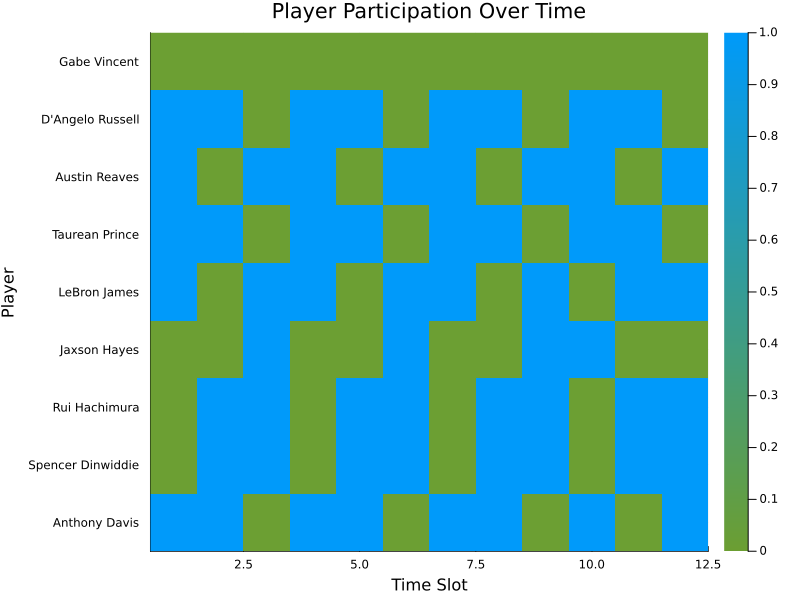

In [5]:
using Plots

time_slots = 1:12
# Creating a heatmap to show who is on the court during different time slots. 
heatmap(
    time_slots, 
    name,
    x_sol,
    c = [0; 1],             
    xlabel = "Time Slot",      # Label for x-axis
    ylabel = "Player",         # Label for y-axis
    title = "Player Participation Over Time",
    size = (800, 600),         # Adjust plot size
    axis = :on,                 # Turn axes on for better alignment
    #framestyle = :grid
)

### 4.2 How Sensitive is our Result?

We will change our constraint 2 and 3, and others remain the same:

Constraint 2: For each time slot, there must be at least 1 and at most 4 forwards on the court at a time.
$$
1 \leq \sum_{i} p_{1, i} x_{i, j} \leq 4, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

Constraint 3: For each time slot, there must be at least 1 and at most 4 forwards on the court at a time. 
$$
1 \leq \sum_{i} p_{2, i} x_{i, j} \leq 4, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

In [6]:
model = Model(GLPK.Optimizer)

@variable(model, x[1:n_players, 1:n_time_slots], Bin)

@objective(model, Max, sum(E[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

@constraint(model, [j in 1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)

#= Adjusting forward and guard constraints this time, 
to allow for more flexibility with which positons are on the court.=#
@constraint(model, [j in 1:n_time_slots], 1 <= sum(p1[i] * x[i, j] for i in 1:n_players) <= 4)
@constraint(model, [j in 1:n_time_slots], 1 <= sum(p2[i] * x[i, j] for i in 1:n_players) <= 4)

@constraint(model, [i in 1:n_players, j in 1:(n_time_slots - 2)], x[i, j] + x[i, j+1] + x[i, j+2] <= 2)

#= Constraint 5: From a coaching standpoint, suppose we want to make sure that the players with 
the 3 highest efficiency ratings start the game on the court. =#
@constraint(model, [i in top_3_eff], x[i, 1] == 1) 

#= Constraint 6: Again, we want our best players to be on the court in the most important moments.
Here we ensure that ehy are also on the court for the last time slot/the end of the game. =#
@constraint(model, [i in top_3_eff], x[i, n_time_slots] == 1)

# Solve the model
optimize!(model)

if termination_status(model) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model))
    x_sol = value.(x)
    println("Player assignments:")
    for i in 1:n_players
        println("$(name[i]): ", [x_sol[i, j] for j in 1:n_time_slots])
        println("$(name[i]) played ", sum([x_sol[i, j] for j in 1:n_time_slots]), " time slots in total.")
    end
else
    println("No optimal solution found.")
end

Optimal solution found:
Objective value: 194.71999999999997
Player assignments:
Anthony Davis: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Anthony Davis played 8.0 time slots in total.
Spencer Dinwiddie: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Spencer Dinwiddie played 8.0 time slots in total.
Rui Hachimura: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Rui Hachimura played 8.0 time slots in total.
Jaxson Hayes: [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0]
Jaxson Hayes played 4.0 time slots in total.
LeBron James: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
LeBron James played 8.0 time slots in total.
Taurean Prince: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Taurean Prince played 8.0 time slots in total.
Austin Reaves: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Austin Reaves played 8.0 time slots in total.
D'Angelo Russell: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0

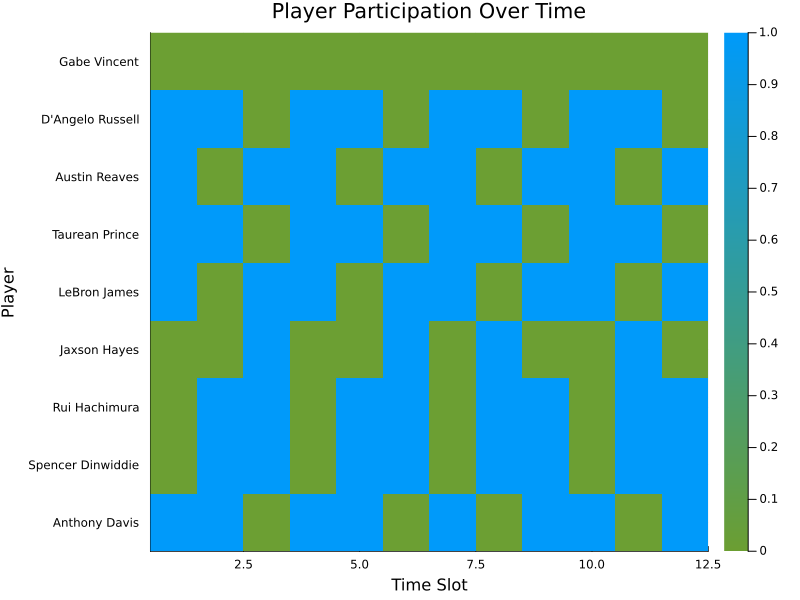

In [7]:
time_slots = 1:12
heatmap(
    time_slots, 
    name,
    x_sol,
    c = [0; 1],             
    xlabel = "Time Slot",      
    ylabel = "Player",         
    title = "Player Participation Over Time",
    size = (800, 600),         
    axis = :on,                 
)

We observe that the result remain the same. This means that our result is not very sensitive to our constraint. 

### 4.3 Maximizing Scoring Rather than Overall Efficiency 

In NBA, point is another key factor that we could potentially considered to help us make the plan. 

Rather than considering overall efficiency, we can consider a strategy to simply prioritize scoring. With this new objective in mind, we calculate points per minute (ppm) and maximize this in our model. 

In this case, we are going to introduce a new data called ppm, indicate the average point for each players can get in 4 mintues time slot. 

In [8]:
ppm = lakers.PTS ./ lakers.MP .* 4 #Initializing our alternaive performance metric. 
top_3_ppm = sortperm(ppm, rev=true)[1:3]

3-element Vector{Int64}:
 5
 1
 7

In this case, our model become:
#### Objective:
$$
\max_{x \in \mathbb{R}^n} \sum_{i}\sum_{j} ppm_i x_{ij}
$$
#### Constraint:

Constraint 1: In each time slot, only 5 players is allowed on the court. 
$$
\sum_{i} x_{ij} = 5,  \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$
 
Constraint 2: For each time slot, there must be at least 2 and at most 3 forwards on the court at a time.
$$
2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

Constraint 3: For each time slot, there must be at least 2 and at most 3 forwards on the court at a time. 
$$
2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

Constraint 4: For each player, he cannot play more than 2 consecutive time slots.
$$
x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \}
$$ 
 
Constraint 5&6: Player with top 3 efficiency score play at the first and last time slot. 
$$
\sum_{i \in I} x_{i, 1} = 1
$$
$$
\sum_{i \in I} x_{i, 12} = 1
$$

Collectively, we will have:
$$
\begin{aligned}
\underset{x \in \mathbb{R^n}}{\text{maximize}}\qquad& \sum_{i}\sum_{j} ppm_i x_{ij} \\
\text{subject to:}\qquad& \sum_{i} x_{ij} = 5  \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \} \\
& \sum_{i \in I} x_{i, 1} = 1 \\
& \sum_{i \in I} x_{i, 12} = 1
\end{aligned}
$$

Optimal solution found:
Objective value: 97.99361775039955
Player assignments:
Anthony Davis: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Anthony Davis played 8.0 time slots in total.
Spencer Dinwiddie: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Spencer Dinwiddie played 8.0 time slots in total.
Rui Hachimura: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Rui Hachimura played 8.0 time slots in total.
Jaxson Hayes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Jaxson Hayes played 0.0 time slots in total.
LeBron James: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
LeBron James played 8.0 time slots in total.
Taurean Prince: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Taurean Prince played 8.0 time slots in total.
Austin Reaves: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0]
Austin Reaves played 8.0 time slots in total.
D'Angelo Russell: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.

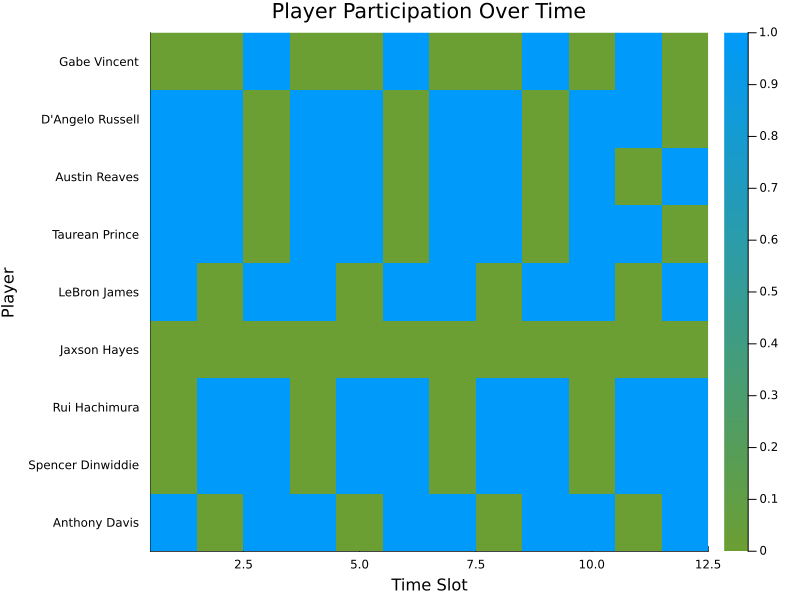

In [9]:
#= Our optimizer, deision variable, and constraints remain the same but we change the objective to maximize 
points per minute instead. =#
model = Model(GLPK.Optimizer)

@variable(model, x[1:n_players, 1:n_time_slots], Bin)

@objective(model, Max, sum(ppm[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

@constraint(model, [j in 1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p1[i] * x[i, j] for i in 1:n_players) <= 3)
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p2[i] * x[i, j] for i in 1:n_players) <= 3)
@constraint(model, [i in 1:n_players, j in 1:(n_time_slots - 2)], x[i, j] + x[i, j+1] + x[i, j+2] <= 2)
@constraint(model, [i in top_3_ppm], x[i, 1] == 1) 
@constraint(model, [i in top_3_ppm], x[i, n_time_slots] == 1)

optimize!(model)

if termination_status(model) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model))
    x_sol = value.(x)
    println("Player assignments:")
    for i in 1:n_players
        println("$(name[i]): ", [x_sol[i, j] for j in 1:n_time_slots])
        println("$(name[i]) played ", sum([x_sol[i, j] for j in 1:n_time_slots]), " time slots in total.")
    end
else
    println("No optimal solution found.")
end

heatmap(
    time_slots, 
    name,
    x_sol,
    c = [0 "white"; 1 "black"],             
    xlabel = "Time Slot",      
    ylabel = "Player",         
    title = "Player Participation Over Time",
    size = (800, 600),         
    axis = :on,                 
)

### 4.4 Condidering Both Efficiency and Points Per Minute, More Emphasis on Efficiency

If we considered both efficiency and score for the game, then the optimization model can change as following:
In this case, our model become:
#### Objective:
$$
\max_{x \in \mathbb{R}^n} \sum_{i}\sum_{j} ppm_i x_{ij} + \lambda * \sum_{i}\sum_{j} E_i x_{ij}
$$
#### Constraint:

Constraint 1: In each time slot, only 5 players is allowed on the court. 
$$
\sum_{i} x_{ij} = 5,  \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$
 
Constraint 2: For each time slot, there must be at least 2 and at most 3 forwards on the court at a time.
$$
2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

Constraint 3: For each time slot, there must be at least 2 and at most 3 forwards on the court at a time. 
$$
2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \}
$$

Constraint 4: For each player, he cannot play more than 2 consecutive time slots.
$$
x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \}
$$ 
 
Constraint 5&6: Player with top 3 efficiency score play at the first and last time slot. 
$$
\sum_{i \in I} x_{i, 1} = 1
$$
$$
\sum_{i \in I} x_{i, 12} = 1
$$

Collectively, we will have:
$$
\begin{aligned}
\underset{x \in \mathbb{R^n}}{\text{maximize}}\qquad& \sum_{i}\sum_{j} ppm_i x_{ij} \\
\text{subject to:}\qquad& \sum_{i} x_{ij} = 5  \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{1, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& 2 \leq \sum_{i} p_{2, i} x_{i, j} \leq 3, \forall j \in \{1, 2, 3,  \cdots, 12 \} \\
& x_{i,j} + x_{i,j+1} + x_{i,j+2} \leq 2, \forall i \in \{1, 2, \dots, 9 \},  j \in \{1, 2, 3, \cdots 10 \} \\
& \sum_{i \in I} x_{i, 1} = 1 \\
& \sum_{i \in I} x_{i, 12} = 1
\end{aligned}
$$

Optimal solution found:
Objective value: 195.69170429344598
Player assignments:
Anthony Davis: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0]
Anthony Davis played 8.0 time slots in total.
Spencer Dinwiddie: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Spencer Dinwiddie played 8.0 time slots in total.
Rui Hachimura: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Rui Hachimura played 8.0 time slots in total.
Jaxson Hayes: [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0]
Jaxson Hayes played 4.0 time slots in total.
LeBron James: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0]
LeBron James played 8.0 time slots in total.
Taurean Prince: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Taurean Prince played 8.0 time slots in total.
Austin Reaves: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Austin Reaves played 8.0 time slots in total.
D'Angelo Russell: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0

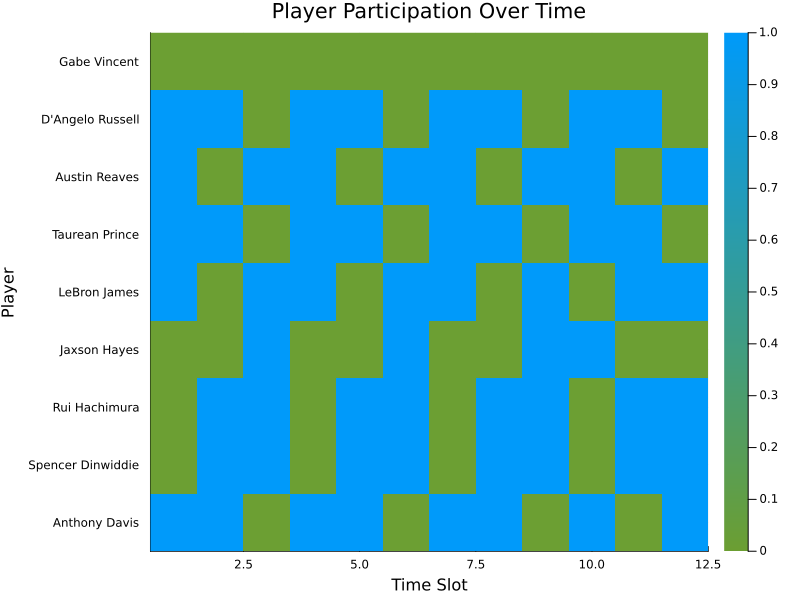

In [10]:
n_players = length(name)
n_time_slots = 12
l = 0.01 #Initializing a small weight applied to points per minute so that there is more emphasis on efficiency. 
#Computing the combined metric to once again to determine which plauers we want to start and finish the game.
combined_metric = [E[i] + l * ppm[i] for i in 1:n_players] 
top_3_combo = sortperm(combined_metric, rev=true)[1:3]

#= Again, we use the same optimizer, decision variable, and constraints but change our objective to include both
efficiency and points per minute with the small weight applied to points per minute. =#
model = Model(GLPK.Optimizer)

@variable(model, x[1:n_players, 1:n_time_slots], Bin) # Binary decision variables

@objective(model, Max, sum(E[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots) + l * sum(ppm[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

@constraint(model, [j in 1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p1[i] * x[i, j] for i in 1:n_players) <= 3)
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p2[i] * x[i, j] for i in 1:n_players) <= 3)
@constraint(model, [i in 1:n_players, j in 1:(n_time_slots - 2)], x[i, j] + x[i, j+1] + x[i, j+2] <= 2)
@constraint(model, [i in top_3_combo], x[i, 1] == 1) # <-- Using the combined metric to determine who starts 
@constraint(model, [i in top_3_combo], x[i, n_time_slots] == 1) # <-- and who finishes the game.

optimize!(model)

if termination_status(model) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model))
    x_sol = value.(x)
    println("Player assignments:")
    for i in 1:n_players
        println("$(name[i]): ", [x_sol[i, j] for j in 1:n_time_slots])
        println("$(name[i]) played ", sum([x_sol[i, j] for j in 1:n_time_slots]), " time slots in total.")
    end
else
    println("No optimal solution found.")
end

heatmap(
    time_slots, 
    name,
    x_sol,
    c = [0; 1],             
    xlabel = "Time Slot",      
    ylabel = "Player",         
    title = "Player Participation Over Time",
    size = (800, 600),         
    axis = :on,                 
)

### 4.5 Putting More Weight on Scoring when Considering Both

Optimal solution found:
Objective value: 1173.5361775039953
Player assignments:
Anthony Davis: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0]
Anthony Davis played 8.0 time slots in total.
Spencer Dinwiddie: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Spencer Dinwiddie played 8.0 time slots in total.
Rui Hachimura: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0]
Rui Hachimura played 8.0 time slots in total.
Jaxson Hayes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Jaxson Hayes played 0.0 time slots in total.
LeBron James: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
LeBron James played 8.0 time slots in total.
Taurean Prince: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0]
Taurean Prince played 8.0 time slots in total.
Austin Reaves: [1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0]
Austin Reaves played 8.0 time slots in total.
D'Angelo Russell: [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0

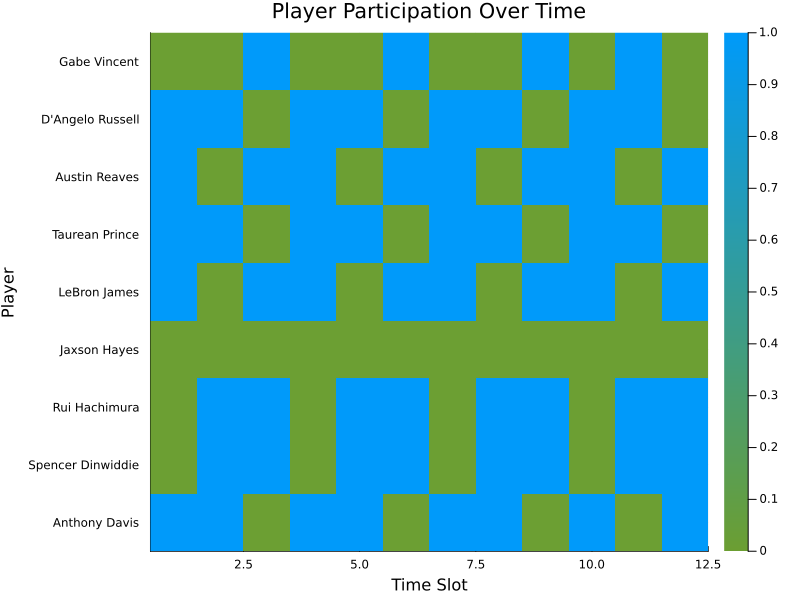

In [11]:
n_players = length(name)
n_time_slots = 12
l = 10 #Increasing weight variable so that there is more emphasis on points per minute. 
#Equation for the combined metric has already been initialized above. 

model = Model(GLPK.Optimizer)

@variable(model, x[1:n_players, 1:n_time_slots], Bin)

@objective(model, Max, sum(E[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots) + l * sum(ppm[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

@constraint(model, [j in 1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p1[i] * x[i, j] for i in 1:n_players) <= 3)
@constraint(model, [j in 1:n_time_slots], 2 <= sum(p2[i] * x[i, j] for i in 1:n_players) <= 3)
@constraint(model, [i in 1:n_players, j in 1:(n_time_slots - 2)], x[i, j] + x[i, j+1] + x[i, j+2] <= 2)
@constraint(model, [i in top_3_combo], x[i, 1] == 1)
@constraint(model, [i in top_3_combo], x[i, n_time_slots] == 1)

optimize!(model)

if termination_status(model) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model))
    x_sol = value.(x)
    println("Player assignments:")
    for i in 1:n_players
        println("$(name[i]): ", [x_sol[i, j] for j in 1:n_time_slots])
        println("$(name[i]) played ", sum([x_sol[i, j] for j in 1:n_time_slots]), " time slots in total.")
    end
else
    println("No optimal solution found.")
end

heatmap(
    time_slots, 
    name,
    x_sol,
    c = [0; 1],             
    xlabel = "Time Slot",      
    ylabel = "Player",         
    title = "Player Participation Over Time",
    size = (800, 600),         
    axis = :on,                 
)

From the trade-off analysis, we can see that when we put more weight on overall efficiency, Jaxson Hayes will be chosen to play in the game, and if we put weight on scores in the game, then Gabe Vincent will be chosen to played in the game. 

### 4.6 Tweaking Our Model to Apply Duality

Instead of using binary variables that determine whether or not a player is playing during a specific time slot, we changed our original model by making our decision variable a continuous value between 0 and 1 that measures the proportion of time a player is on the court during that time slot. The constraints were also adjusted to have 2 constraints for each previous constraint, so that we can get dual values for both the lower and upper constraints. Instead of restricting maximum playing time by limiting consecutive time slots on the court, we set basic minimum and maximum average participation constraints. 

Additionally, we leave out the constraints that ensure that the most efficient players are playing during the first time slot and the last time slot. Since the decision variable now represents the proportion of time a player is on the court during a given time slot, it is less meaningful to make sure that the most efficient players start and finish the game because x[i, j] = 1 no longer indicates that a player is guaranteed to be on the court for a full time slot.

Optimal solution found:
Objective value: 217.82400000000004
Anthony Davis plays on average: 0.8000000000000002
Spencer Dinwiddie plays on average: 0.3
Rui Hachimura plays on average: 0.3
Jaxson Hayes plays on average: 0.3
LeBron James plays on average: 0.8000000000000002
Taurean Prince plays on average: 0.5999999999999996
Austin Reaves plays on average: 0.8000000000000002
D'Angelo Russell plays on average: 0.8000000000000002
Gabe Vincent plays on average: 0.3
Dual variables for court constraints (5 players per slot): [-1.48, -1.48, -1.48, -1.48, -1.48, -1.48, -1.4800000000000004, -1.48, -1.4800000000000009, -1.48, -1.4800000000000004, -1.4800000000000009]
Dual variables for forward constraints (lower bound): [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0]
Dual variables for forward constraints (upper bound): [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]
Dual variables for guard constraints (lower bound): [0.0, 0.0, -0.0, -0.0, 0.0, 0.0

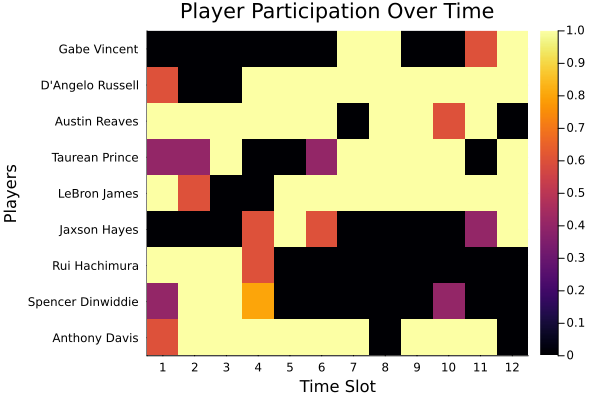

In [12]:
model3 = Model(GLPK.Optimizer)

min_avg_time = 0.3
max_avg_time = 0.8

# Defining decision variables as continuous instead of binary.
@variable(model3, 0 <= x[1:n_players, 1:n_time_slots] <= 1)  # Proportion of time player is on court

# Using the original objective, total efficiency amongst all players. 
@objective(model3, Max, sum(E[i] * x[i, j] for i in 1:n_players, j in 1:n_time_slots))

# Constraint 1: Exactly 5 players on the court per time slot
@constraint(model3, court_constraints[j=1:n_time_slots], sum(x[i, j] for i in 1:n_players) == 5)

# Constraints 2 and 3: Forwards on the court at a time. 
@constraint(model3, forward_constraints_lower[j=1:n_time_slots], sum(p1[i] * x[i, j] for i in 1:n_players) >= 2)
@constraint(model3, forward_constraints_upper[j=1:n_time_slots], sum(p1[i] * x[i, j] for i in 1:n_players) <= 3)

# Constraint 4 and 5: Guards on the court at a time. 
@constraint(model3, guard_constraints_lower[j=1:n_time_slots], sum(p2[i] * x[i, j] for i in 1:n_players) >= 2)
@constraint(model3, guard_constraints_upper[j=1:n_time_slots], sum(p2[i] * x[i, j] for i in 1:n_players) <= 3)

#Constraints 6 and 7: Minimum and maximum average participation. 
@constraint(model3, avg_participation_constraints_lower[i=1:n_players], 
    sum(x[i, j] for j in 1:n_time_slots) >= min_avg_time * n_time_slots)

@constraint(model3, avg_participation_constraints_upper[i=1:n_players], 
    sum(x[i, j] for j in 1:n_time_slots) <= max_avg_time * n_time_slots)

# Solve the model
optimize!(model3)

# Check results
if termination_status(model3) == MOI.OPTIMAL
    println("Optimal solution found:")
    println("Objective value: ", objective_value(model3))
    
    x_sol = value.(x)
    for i in 1:n_players
        println("$(name[i]) plays on average: ", sum(x_sol[i, :]) / n_time_slots)
    end
else
    println("No optimal solution found.")
end

# Dual variables for total players on the court constraint
dual_court_constraints = [dual(court_constraints[j]) for j in 1:n_time_slots]
println("Dual variables for court constraints (5 players per slot): ", dual_court_constraints)

# Dual variables for forward constraints
dual_forward_constraints_lower = [dual(forward_constraints_lower[j]) for j in 1:n_time_slots]
dual_forward_constraints_upper = [dual(forward_constraints_upper[j]) for j in 1:n_time_slots]
println("Dual variables for forward constraints (lower bound): ", dual_forward_constraints_lower)
println("Dual variables for forward constraints (upper bound): ", dual_forward_constraints_upper)

# Dual variables for guard constraints
dual_guard_constraints_lower = [dual(guard_constraints_lower[j]) for j in 1:n_time_slots]
dual_guard_constraints_upper = [dual(guard_constraints_upper[j]) for j in 1:n_time_slots]
println("Dual variables for guard constraints (lower bound): ", dual_guard_constraints_lower)
println("Dual variables for guard constraints (upper bound): ", dual_guard_constraints_upper)

# Dual variables for minimum average participation
dual_avg_participation_lower = [dual(avg_participation_constraints_lower[i]) for i in 1:n_players]
println("Dual variables for minimum average participation: ", dual_avg_participation_lower)

# Dual variables for maximum average participation
dual_avg_participation_upper = [dual(avg_participation_constraints_upper[i]) for i in 1:n_players]
println("Dual variables for maximum average participation: ", dual_avg_participation_upper)

using Plots
heatmap(x_sol, xlabel="Time Slot", ylabel="Players", title="Player Participation Over Time",
    xticks=1:n_time_slots, yticks=(1:n_players, name))

In this heatmap, the times for which we want certain players to be on the court is more realistically portrayed, since players are playing for a portion of the game and are not guaranteed to be on the court or not for the course of the entire time slot. 

Below, we include a bar chart to better display the comparison of average player participation between each player.

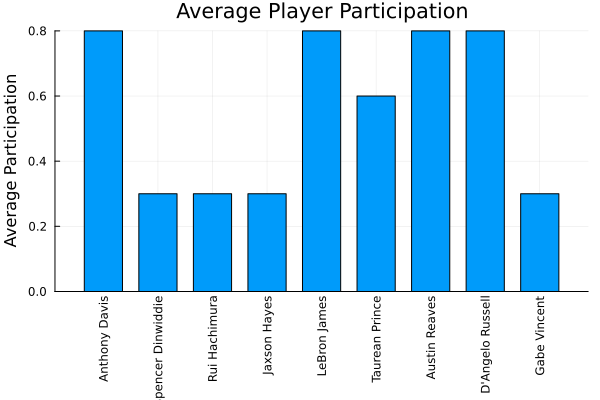

In [13]:
avg_participation = [sum(x_sol[i, :]) / n_time_slots for i in 1:n_players]

bar(name, avg_participation, xlabel="Players", ylabel="Average Participation",
    title="Average Player Participation", legend=false, bar_width=0.7, xrotation=90)

The bar graph below displays the dual values for the minimum average participation. A positive dual value here means that relaxing the constraint (reducing the minimum participation requirement for a player) would decrease the objective value (team efficiency). In other words, the constraint is binding, and the player's minimum participation is necessary to achieve the current optimal efficiency. This makes sense, considering that our minimum participation constraint is simulating the fatigue of other players by assuming that all players need to play because others will tire. 

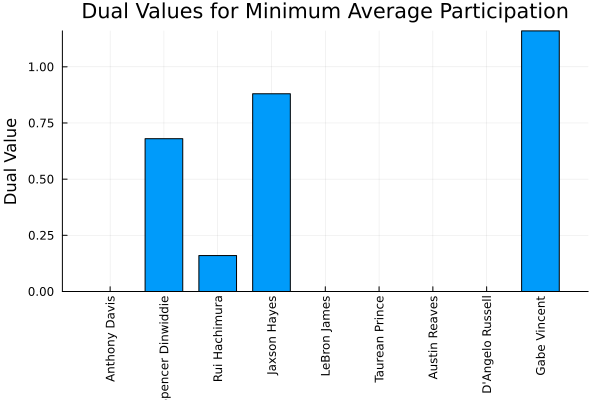

In [14]:
bar(name, dual_avg_participation_lower, xlabel="Players", ylabel="Dual Value",
    title="Dual Values for Minimum Average Participation", legend=false, bar_width=0.7, xrotation=90)

Showing the dual values for maximum average participation accomplishes a similar feat. Negative dual values here show us that increasing their participation beyond the current limit would decrease team efficiency. Although the plauers with the lowest dual values are our best players, this agrees with our constraints and reflects fatigure because these players are playing the maximum amount of time that they can play. Overusing these players could disrupt lineup balance and prevent other players from fulfilling critical roles.

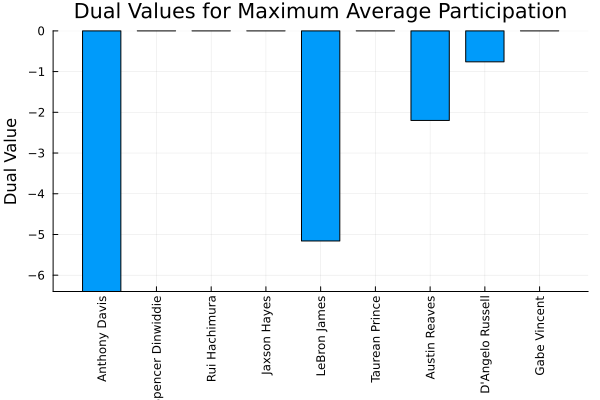

In [15]:
bar(name, dual_avg_participation_upper, xlabel="Players", ylabel="Dual Value",
    title="Dual Values for Maximum Average Participation", legend=false, bar_width=0.7, xrotation=90)

### 4.7 Limitation ###
One limitation in our current model is that, the real game can be more complicated than what we can implement right now. While we make the assumption that each time gap between the player changes is 4 minutes (by average), the actual time can be vary based on the situation. 
Another limitation on the model is that the standard to determine if a player should play in game or not can be affect by more variable than the Efficiency and point scored per slot. Therefore, the situation may be varied in different senario. We are implementing the model based on the average case. 

## 5. Conclusion ##

In summary, we found that based on our current strategy 

### Future Direction ###
One possible future direction we can continue on this project is to calcualte the optimal maximum number of time for each player can play in a game. Unfortunately, there is not meaningful data available that can effectively represent fatigue so that we can assess a player's physical regression as they tire. A future implementation can include overtime periods as well. 

Another interesting follow-up we could pursue is to take into account player injuries, which are frequent in the NBA; players rarely play in all 82 games of the regular season. 

## 6. Author Contributions

Note: The contributions in each category must sum to 100%. See Canvas for more details on what type of work belongs in each category.

#### 1. Modelling  
Student A: Percentage contribution 33.33%  
Student B: Percentage contribution 33.33%  
Student C: Percentage contribution 33.33%  

  
#### 2. Analysis  
Student A: Percentage contribution 33.33%  
Student B: Percentage contribution 33.33%  
Student C: Percentage contribution 33.33%  


#### 3. Data Gathering  
Student A: Percentage contribution 33.33%  
Student B: Percentage contribution 33.33%  
Student C: Percentage contribution 33.33%  


#### 4. Software Implementation  
Student A: Percentage contribution 33.33%  
Student B: Percentage contribution 33.33%  
Student C: Percentage contribution 33.33%  


#### 5. Report Writing    
Student A: Percentage contribution 33.33%  
Student B: Percentage contribution 33.33%  
Student C: Percentage contribution 33.33%  